In [1]:
# Data Science/AI Capstone Project #2

# Kaggle Boston Housing Dataset

In [2]:
# First, uninstall the current scipy version
!pip uninstall -y scipy

# Then install numpy first to ensure we have a stable base
!pip install --upgrade numpy

# Now install a compatible scipy version
# Uncomment the following line to install scipy
!pip install scipy

# Wait a moment for installation to complete
import time
time.sleep(5)  # Give some time for installation to complete

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # Now scipy should be properly imported
# get matplot to show charts inline
%matplotlib inline
import plotly.graph_objects as go
import plotly.express as px

from sklearn import datasets
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression


# import the LinearRegression class from the sklearn.linear_model module
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.feature_selection import SequentialFeatureSelector


# Cross validation
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

# Regularization
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error

# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import statsmodels.api as sm

## Avoid some version change warnings
import warnings
warnings.filterwarnings('ignore', message='numpy.dtype size changed')

#!pip install folium
#import folium

Found existing installation: scipy 1.17.0
Uninstalling scipy-1.17.0:
  Successfully uninstalled scipy-1.17.0
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datashader 0.18.0 requires scipy, which is not installed.
imbalanced-learn 0.13.0 requires scipy<2,>=1.10.1, which is not installed.
scikit-image 0.25.0 requires scipy>=1.11.2, which is not installed.
scikit-learn 1.6.1 requires scipy>=1.6.0, which is not installed.
shap 0.50.0 requires scipy, which is not installed.
statsmodels 0.14.4 requires scipy!=1.9.2,>=1.8, which is not installed.
sweetviz 2.3.1 requires scipy>=1.3.2, which is not installed.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.2 which is incompatible.


  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl (36.3 MB)


In [3]:
df = pd.read_csv("BostonHousing.csv")
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.shape

(506, 14)

In [5]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [6]:
df.dtypes.value_counts()

float64    11
int64       3
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [8]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [9]:
df.index

RangeIndex(start=0, stop=506, step=1)

In [10]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [11]:
df.values

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 3.9690e+02, 4.9800e+00,
        2.4000e+01],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 3.9690e+02, 9.1400e+00,
        2.1600e+01],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 3.9283e+02, 4.0300e+00,
        3.4700e+01],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 3.9690e+02, 5.6400e+00,
        2.3900e+01],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 3.9345e+02, 6.4800e+00,
        2.2000e+01],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 3.9690e+02, 7.8800e+00,
        1.1900e+01]], shape=(506, 14))

In [12]:
# Load and split

ffs = pd.read_csv("BostonHousing.csv")

# Take all columns except target as predictor columns
predictor_columns = [c for c in ffs.columns if c != 'medv']
# Load the dataset as a pandas data frame
X = pd.DataFrame(ffs, columns = predictor_columns)
# Target
y = ffs['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
# Ridge Model

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5))
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)


In [14]:
# Lasso Model

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, max_iter=10000))
])

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)


In [15]:
# Forward Feature Selection

ols = LinearRegression()

sfs = SequentialFeatureSelector(
    ols,
    n_features_to_select=5,
    direction='forward',
    cv=5
)

sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()]
X_train_sfs = X_train[selected_features]
X_test_sfs = X_test[selected_features]

ols.fit(X_train_sfs, y_train)
ffs_pred = ols.predict(X_test_sfs)


In [16]:
# Gradient Boosting

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)


In [17]:
# Model Comparison

def evaluate(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = []

results.append(evaluate("Ridge", y_test, ridge_pred))
results.append(evaluate("Lasso", y_test, lasso_pred))
results.append(evaluate("FFS + OLS", y_test, ffs_pred))
results.append(evaluate("Gradient Boosting", y_test, gbr_pred))

results_df = pd.DataFrame(results)
print(results_df)


               Model        R²      RMSE
0              Ridge  0.667916  4.934871
1              Lasso  0.668713  4.928949
2          FFS + OLS  0.606108  5.374533
3  Gradient Boosting  0.915334  2.491759


In [18]:
# Cross Validated R^2 Comparison

models = {
    "Ridge": ridge,
    "Lasso": lasso,
    "Gradient Boosting": gbr
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_results[name] = scores.mean()

# FFS requires special handling
X_sfs = X[X.columns[sfs.get_support()]]
scores_sfs = cross_val_score(ols, X_sfs, y, cv=5, scoring='r2')
cv_results["FFS + OLS"] = scores_sfs.mean()

print(cv_results)


{'Ridge': np.float64(0.46236101888953185), 'Lasso': np.float64(0.3922461113288103), 'Gradient Boosting': np.float64(0.6745677868708551), 'FFS + OLS': np.float64(0.4506064346805979)}


In [19]:
# Lasso Selected Features

lasso_coef = lasso.named_steps['lasso'].coef_
lasso_selected = X.columns[lasso_coef != 0]
print("Lasso Selected:", lasso_selected)


Lasso Selected: Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat'],
      dtype='object')


In [20]:
# FFS selected Features

print("FFS Selected:", selected_features)


FFS Selected: Index(['rm', 'dis', 'ptratio', 'b', 'lstat'], dtype='object')


In [21]:
# Gradient Boosting Feature Ranking

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head())


    Feature  Importance
5        rm    0.417416
12    lstat    0.374326
7       dis    0.074700
4       nox    0.032868
10  ptratio    0.030102


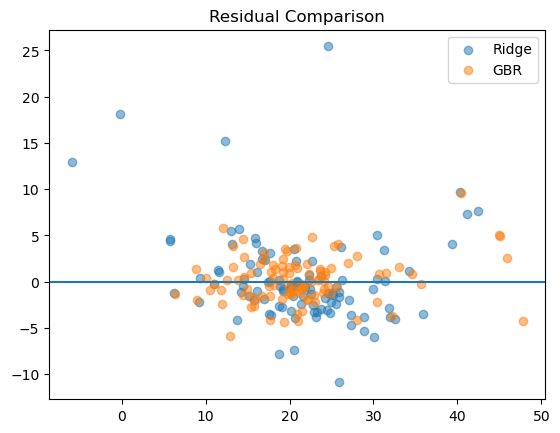

In [22]:
plt.figure()
plt.scatter(ridge_pred, y_test - ridge_pred, label="Ridge", alpha=0.5)
plt.scatter(gbr_pred, y_test - gbr_pred, label="GBR", alpha=0.5)
plt.axhline(0)
plt.legend()
plt.title("Residual Comparison")
plt.show()
